In [8]:
from sklearn.ensemble import IsolationForest

# Re-apply Isolation Forest to ensure 'anomaly' column exists in df
# (This is added here for robustness in case the previous cell defining 'anomaly' was not run or its state was lost)
model = IsolationForest(contamination=0.05, random_state=42) # Re-initialize model
df['anomaly'] = model.fit_predict(df[['value']])

# Filter out the anomalies to show only the normal data points
normal_data = df[df['anomaly'] == 1]

print("Original time series data without anomalies:")
display(normal_data.head())

Original time series data without anomalies:


,value,anomaly
timestamp,,
2023-01-01 00:00:00,102.483571,1
2023-01-01 01:00:00,99.308678,1
2023-01-01 02:00:00,103.238443,1
2023-01-01 03:00:00,107.615149,1
2023-01-01 04:00:00,98.829233,1


In [5]:
print("Detected Anomalies:")
display(anomalies)

print("\nSummary statistics for anomalous values:")
display(anomalies['value'].describe())

Detected Anomalies:


,value,anomaly
timestamp,,
2023-01-03 02:00:00,120.000000,-1
2023-01-03 03:00:00,130.000000,-1
2023-01-03 04:00:00,125.000000,-1
2023-01-04 02:00:00,86.901274,-1
2023-01-05 04:00:00,70.000000,-1
2023-01-05 05:00:00,65.000000,-1
2023-01-05 17:00:00,112.316211,-1
2023-01-06 05:00:00,110.952278,-1
2023-01-07 06:00:00,140.000000,-1



Summary statistics for anomalous values:


,value
count,10.000000
mean,107.377061
std,25.241040
min,65.000000
25%,92.914025
50%,112.958528
75%,123.750000
max,140.000000


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Generate synthetic time series data with anomalies
np.random.seed(42)

# Normal data
dates = pd.date_range(start='2023-01-01', periods=200, freq='h')
data = np.random.normal(loc=100, scale=5, size=200)

# Introduce some anomalies
data[50:53] = [120, 130, 125] # High values
data[100:102] = [70, 65]    # Low values
data[150] = 140            # Single spike

df = pd.DataFrame({'timestamp': dates, 'value': data})
df.set_index('timestamp', inplace=True)

print("Generated synthetic time series data:")
display(df.head())

Generated synthetic time series data:


,value
timestamp,
2023-01-01 00:00:00,102.483571
2023-01-01 01:00:00,99.308678
2023-01-01 02:00:00,103.238443
2023-01-01 03:00:00,107.615149
2023-01-01 04:00:00,98.829233


In [2]:
# 2. Apply Isolation Forest for anomaly detection

# Initialize the Isolation Forest model
# contamination: the proportion of outliers in the data set.
# Adjust this based on your expectation of anomaly percentage.
model = IsolationForest(contamination=0.05, random_state=42)

# Fit the model and predict anomalies
# -1 indicates an outlier, 1 indicates an inlier
df['anomaly'] = model.fit_predict(df[['value']])

# Separate anomalies from normal data
anomalies = df[df['anomaly'] == -1]

print("Data with anomaly predictions:")
display(df.head())

Data with anomaly predictions:


,value,anomaly
timestamp,,
2023-01-01 00:00:00,102.483571,1
2023-01-01 01:00:00,99.308678,1
2023-01-01 02:00:00,103.238443,1
2023-01-01 03:00:00,107.615149,1
2023-01-01 04:00:00,98.829233,1


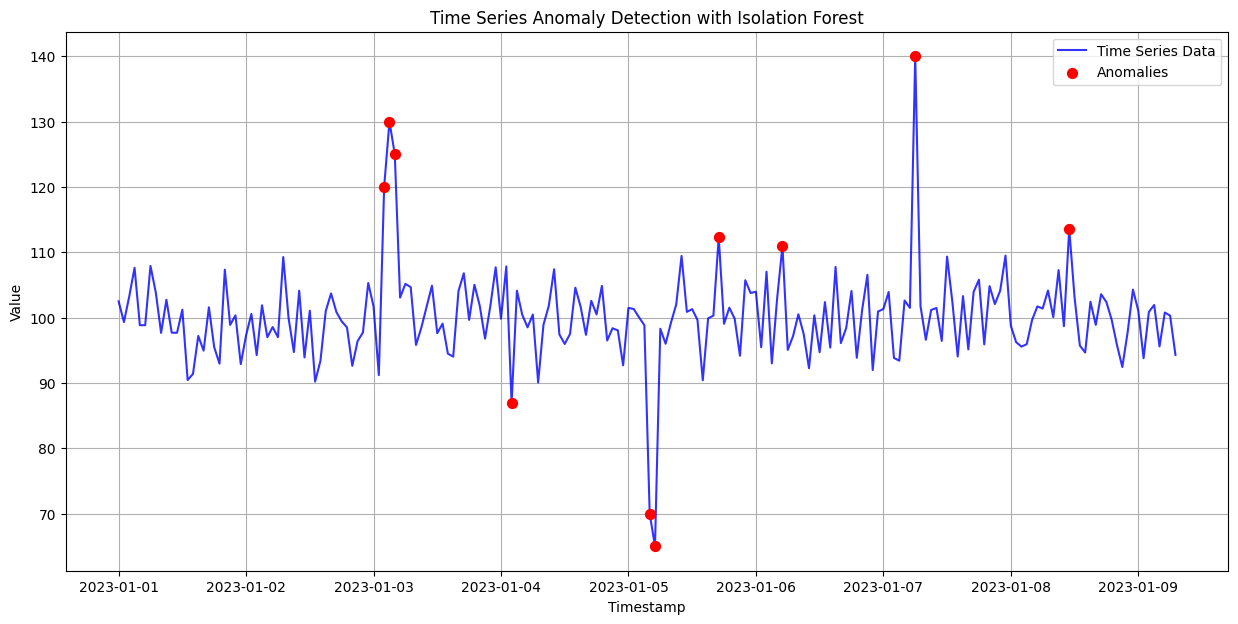

In [3]:
# 3. Visualize the results

plt.figure(figsize=(15, 7))
plt.plot(df.index, df['value'], label='Time Series Data', color='blue', alpha=0.8)
plt.scatter(anomalies.index, anomalies['value'], color='red', label='Anomalies', s=50, zorder=5)

plt.title('Time Series Anomaly Detection with Isolation Forest')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()